# Introduction

Fortunately, with libraries such as Scikit-Learn, it’s now easy to build and use almost any machine learning algorithm. But it’s helpful to have an idea of how a machine learning model works under the hood. This lets us diagnose the model when it’s underperforming or explain how it makes decisions, which is crucial if we want to convince others to trust our models.
In this assignment, we’ll look at how to build and use the Decision Tree and the Random Forest in Python. We’ll start by understanding how a single decision tree makes classifications on a simple problem. Then, we’ll work our way to using a random forest on a real-world data science problem.

# Dataset

The dataset we will use in this assignment is the Sonar dataset.

This is a dataset that describes sonar chirp returns bouncing off different surfaces. The 60 predictors are the strength of the returns at different angles. It is a binary classification problem that requires a model to differentiate rocks from metal cylinders. There are 208 observations.

It is a well-understood dataset. All of the variables are continuous and generally in the range of 0 to 1. The output variable is a string “M” for mine and “R” for rock, which will need to be converted to integers 1 and 0.

By predicting the class with the most observations in the dataset (M or mines) the Zero Rule Algorithm can achieve an accuracy of 53%.

You can learn more about this dataset at the UCI Machine Learning repository.
https://archive.ics.uci.edu/ml/datasets/Connectionist+Bench+(Sonar,+Mines+vs.+Rocks)

Download the dataset for free and place it in the "data" folder in your working directory with the filename sonar.all-data.csv.

# Import section

In [1]:
import random
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

np.random.seed(2020)
random.seed(2020)

# Preprocess data

Read data and convert targets to integers 1 and 0.

In [3]:
PATH = 'data/'
df = pd.read_csv(PATH+'sonar-all-data.csv', header=None)
df.columns = [f'feat_{col}' if col!=60 else 'target' for col in df.columns]
df['target'] = df['target'].map({'M': 1, 'R': 0})
df.head()

,feat_0,feat_1,feat_2,feat_3,feat_4,feat_5,feat_6,feat_7,feat_8,feat_9,...,feat_51,feat_52,feat_53,feat_54,feat_55,feat_56,feat_57,feat_58,feat_59,target
0,0.0200,0.0371,0.0428,0.0207,0.0954,0.0986,0.1539,0.1601,0.3109,0.2111,...,0.0027,0.0065,0.0159,0.0072,0.0167,0.0180,0.0084,0.0090,0.0032,0
1,0.0453,0.0523,0.0843,0.0689,0.1183,0.2583,0.2156,0.3481,0.3337,0.2872,...,0.0084,0.0089,0.0048,0.0094,0.0191,0.0140,0.0049,0.0052,0.0044,0
2,0.0262,0.0582,0.1099,0.1083,0.0974,0.2280,0.2431,0.3771,0.5598,0.6194,...,0.0232,0.0166,0.0095,0.0180,0.0244,0.0316,0.0164,0.0095,0.0078,0
3,0.0100,0.0171,0.0623,0.0205,0.0205,0.0368,0.1098,0.1276,0.0598,0.1264,...,0.0121,0.0036,0.0150,0.0085,0.0073,0.0050,0.0044,0.0040,0.0117,0
4,0.0762,0.0666,0.0481,0.0394,0.0590,0.0649,0.1209,0.2467,0.3564,0.4459,...,0.0031,0.0054,0.0105,0.0110,0.0015,0.0072,0.0048,0.0107,0.0094,0


# Split data (train and test)

In [4]:
X_train, X_test, y_train, y_test = train_test_split(df.drop(columns='target'), df['target'], test_size=0.2, random_state=2020)

# Cost functions

In this section you should implement two cost functions. Any of these can be used in the model.

## Gini index

In [5]:
def gini_index(x):
    """ Calculate Gini Index for a node
    Args:
        x: Numpy-array of targets in a node
    Returns:
        float: Gini index
    """    
    if len(x) == 0:
        return 0.0
    p = np.bincount(x) / len(x)
    return 1 - np.sum(p*p)

In [6]:
target = df['target'].values
gini_index(target)

0.4977348372781065

In [7]:
def gini_gain(parent_node, splits):
    """ Calculate Gini Gain for a particular split
    Args:
        parent_node: Numpy-array of targets in a parent node
        splits: List of two numpy-arrays. Each numpy-array is targets in a child node
    Returns:
        float: Gini gain
    """       
    splits_gini = np.sum([gini_index(split)*(len(split)/len(parent_node)) for split in splits])
    return gini_index(parent_node) - splits_gini

In [8]:
splits = [np.random.choice(df['target'].values, 100), np.random.choice(df['target'].values, 108)]
gini_gain(target, splits)

-0.0003705758273065962

## Entropy

In [9]:
def entropy(x):
    """ Calculate Entropy for a node
    Args:
        x: Numpy-array of targets in a node
    Returns:
        float: Entropy
    """
    if len(x) == 0:
        return 0.0
    p = np.clip(np.bincount(x) / len(x), 1e-15, 1.)
    return -np.sum(p * np.log(p))

In [10]:
def information_gain(parent_node, splits):
    """ Calculate Information Gain for a particular split
    Args:
        parent_node: Numpy-array of targets in a parent node
        splits: List of two numpy-arrays. Each numpy-array is targets in a child node
    Returns:
        float: Information Gain
    """     
    splits_entropy = np.sum([entropy(split)*(len(split)/len(parent_node)) for split in splits])
    return entropy(parent_node) - splits_entropy

# Split function

Implement split functions

In [2]:
def split(X, y, value):
    """ Split y-values in order to calculate gain later
    Args:
        X: 1-dimensional numpy-array of data predictor with shape (N,)
        y: 1-dimensional numpy-array of targets with shape (N,)
        value (float): the value by which the X should be splitted
    Returns:
        Two 1-dimensional numpy-arrays with targets related to splits
    """      
    left_mask = X < value
    right_mask = X >= value
    return y[left_mask], y[right_mask]


def split_dataset(X, y, column, value):
    """ Split dataset by a particular column and value
    Args:
        X: 2-dimensional numpy-array (N, num_feats). N-number of samples
        y: 1-dimensional numpy-array of targets with shape (N,)  
        column (int): the column by which the X should be splitted
        value (float): the value by which the column should be splitted
    Returns:
        Two 2-dimensional numpy-arrays with data and two 1-dimensional numpy-arrays with targets related to splits
        left_X, right_X, left_y, right_y
    """       
    left_mask = X[:, column] < value
    right_mask = X[:, column] >= value
    left_y, right_y = y[left_mask], y[right_mask]
    left_X, right_X = X[left_mask], X[right_mask]
    return left_X, right_X, left_y, right_y

# Decision tree

In [12]:
class Tree(object):
    """A decision tree classifier.

    Args:
        criterion : {"gini_gain", "information_gain"}
    """
    def __init__(self, criterion=None):
        self.impurity = None
        self.threshold = None
        self.column_index = None
        self.outcome_probs = None
        self.criterion = criterion
        self.left_child = None
        self.right_child = None

    @property
    def is_terminal(self):
        """ Define is it terminal node
        """          
        return not bool(self.left_child and self.right_child)

    def _find_splits(self, X):
        """Find all possible split values."""
        split_values = set()

        # Get unique values in a sorted order
        x_unique = list(np.unique(X))
        for i in range(1, len(x_unique)):
            # Find a point between two values
            average = (x_unique[i - 1] + x_unique[i]) / 2.0
            split_values.add(average)

        return list(split_values)

    def _find_best_split(self, X, y, n_features):
        """Find best feature and value for a split. Greedy algorithm."""

        # Sample random subset of features
        subset = random.sample(list(range(0, X.shape[1])), n_features)
        max_gain, max_col, max_val = None, None, None

        for column in subset:
            split_values = self._find_splits(X[:, column])
            for value in split_values:
                splits = split(X[:, column], y, value)
                gain = self.criterion(y, splits)

                if (max_gain is None) or (gain > max_gain):
                    max_col, max_val, max_gain = column, value, gain
        return max_col, max_val, max_gain

    def fit(self, X, y, n_features=None, max_depth=None):
        """Fit model.

        Args:
            X (numpy-array): The training input samples. 2-dimensional numpy array.
            y (numpy-array): The target values. 1-dimensional numpy array.
            n_features (int): The number of features when fit is performed (default: all features)
            max_depth (int): The maximum depth of the tree. If None, then nodes are expanded until
                             all leaves are pure.
        """        
        try:
            # Exit from recursion using assert syntax
            if max_depth is not None:
                assert max_depth > 0
                max_depth -= 1

            if n_features is None:
                n_features = X.shape[1]

            column, value, gain = self._find_best_split(X, y, n_features)
            assert gain is not None

            self.column_index = column
            self.threshold = value
            self.impurity = gain

            # Split dataset
            left_X, right_X, left_target, right_target = split_dataset(X, y, column, value)

            # Grow left and right child
            self.left_child = Tree(self.criterion)
            self.left_child.fit(
                left_X, left_target, n_features, max_depth
            )

            self.right_child = Tree(self.criterion)
            self.right_child.fit(
                right_X, right_target, n_features, max_depth
            )
        except AssertionError:
            self.outcome_probs = np.around(np.sum(y) / y.shape[0])


    def predict_row(self, row):
        """Predict single row."""
        if not self.is_terminal:
            if row[self.column_index] < self.threshold:
                return self.left_child.predict_row(row)
            else:
                return self.right_child.predict_row(row)
        return self.outcome_probs

    def predict(self, X):
        """Make predictions.

        Args:
            X (numpy-array): The test input samples. 2-dimensional numpy array.
        """  
        result = np.zeros(X.shape[0])
        for i in range(X.shape[0]):
            result[i] = self.predict_row(X[i, :])
        return result

Fit two models with "max_depth=3" and "max_depth=None" hyperparameters. Explain the results.

In [13]:
model = Tree(criterion=gini_gain)
model.fit(X_train.values, y_train.values)
y_pred = model.predict(X_test.values)
print(f"Accuracy score is: {accuracy_score(y_test, y_pred)}")

Accuracy score is: 0.6666666666666666


In [14]:
model = Tree(criterion=gini_gain)
model.fit(X_train.values, y_train.values, max_depth=3)
y_pred = model.predict(X_test.values)
print(f"Accuracy score is: {accuracy_score(y_test, y_pred)}")

Accuracy score is: 0.6666666666666666


In [15]:
model = Tree(criterion=information_gain)
model.fit(X_train.values, y_train.values, max_depth=3)
y_pred = model.predict(X_test.values)
print(f"Accuracy score is: {accuracy_score(y_test, y_pred)}")

Accuracy score is: 0.7380952380952381


# Random forest

In [16]:
class RandomForestClassifier(object):
    """
    A random forest classifier.
    A random forest is a meta estimator that fits a number of decision tree
    classifiers on various sub-samples of the dataset and uses averaging to
    improve the predictive accuracy and control overfitting.
    
    Args:
        n_estimators : int, default=10
            The number of trees in the forest.

        max_depth : int, default=None
            The maximum depth of the tree. If None, then nodes are expanded until
            all leaves are pure.        

        n_features : int, default=None
            The number of features to consider when looking for the best split.
            If None, then `n_features=sqrt(n_features)`.

        criterion : {"gini", "entropy"}, default="gini"
            The function to measure the quality of a split. Supported criteria are
            "gini" for the Gini impurity and "entropy" for the information gain.
    """

    def __init__(self, n_estimators=10, max_depth=None, n_features=None, criterion="entropy", bootstrap=True):
        self.n_estimators = n_estimators
        self.max_depth = max_depth
        self.n_features = n_features
        self.bootstrap = bootstrap
        
        if criterion == "entropy":
            self.criterion = information_gain
        elif criterion == "gini":
            self.criterion = gini_gain
        else:
            raise ValueError(f"Unknown criterion '{criterion}'")
            
        self.trees = [Tree(criterion=self.criterion) for _ in range(n_estimators)]
        
    def _init_data(self, X, y):
        """Ensure data are in the expected format.
        Ensures X and y are stored as numpy ndarrays by converting from an
        array-like object if necessary. 
        Parameters
        Args:
            X : array-like
                Feature dataset.
            y : array-like, default=None
                Target values. By default is required, but if y_required = false
                then may be omitted.
        """
        self.size = len(X)
        
        if not isinstance(X, np.ndarray):
            self.X = np.array(X)
        else:
            self.X = X

        if not isinstance(y, np.ndarray):
            self.y = np.array(y)
        else:
            self.y = y
            
    def bootstrap_data(self, size):
        return np.random.randint(size, size=size)
    
    def fit(self, X, y):
        """Fit model.

        Args:
            X (numpy-array): The training input samples. 2-dimensional numpy array.
            y (numpy-array): The target values. 1-dimensional numpy array.
        """         
        if self.n_features is None:
            self.n_features = int(np.sqrt(X.shape[1]))
        elif X.shape[1] < self.n_features:
            raise ValueError(f"'n_features should be <= n_features'")
            
        self._init_data(X, y)
        
        for tree in self.trees:
            if self.bootstrap:
                idxs = self.bootstrap_data(self.size)
                X = self.X[idxs]
                y = self.y[idxs]
            else:
                X = self.X
                y = self.y
                
            tree.fit(
                X,
                y,
                n_features=self.n_features,
                max_depth=self.max_depth,
            )
            
    def predict(self, X):
        """Make predictions.

        Args:
            X (numpy-array): The test data input samples. 2-dimensional numpy array.
        """            
        if not isinstance(X, np.ndarray):
            X = np.array(X)

        if self.X is not None:
            predictions = np.zeros(len(X))
            for i in range(len(X)):
                row_pred = 0.
                for tree in self.trees:
                    row_pred += tree.predict_row(X[i, :])

                row_pred /= self.n_estimators
                predictions[i] = round(row_pred)
            return predictions  
        else:
            raise ValueError("You should fit a model before `predict`")

Fit two models with "n_estimators=10" and "n_estimators=100" hyperparameters. Explain the results.

In [17]:
model = RandomForestClassifier(n_estimators=10, max_depth=None, n_features=None, criterion="entropy")
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
print(f"Accuracy score is: {accuracy_score(y_test, y_pred)}")

Accuracy score is: 0.7380952380952381


In [18]:
model = RandomForestClassifier(n_estimators=100, max_depth=None, n_features=None, criterion="entropy")
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
print(f"Accuracy score is: {accuracy_score(y_test, y_pred)}")

Accuracy score is: 0.8809523809523809


Now it's your turn to explore the various parameters of sklearn [RandomForestClassifier](https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.RandomForestClassifier.html) and their influence on model quality.

# Homework part 1. RandomForestClassifier

_Note_: Consider **accuracy** as main metric of model performance on this dataset.

In [105]:
from sklearn.ensemble import RandomForestClassifier

**Task 1 (0.5 points)** Split the dataset into train, test and validation parts (0.6 / 0.2 / 0.2). First two will be used for model hyperparameter tuning whereas the best model quality should be evaluated on validation part.

In [19]:
X = df.drop(columns='target')
y = df['target']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=1)

X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.25, random_state=1) # 0.25 x 0.8 = 0.2

**Task 2 (2 points)**. Apply '_greedy_' hyperparameter tuning of RandomForestClassifier model. '_Greedy_' way means the following general approach. At first we tune one model parameter whereas others are fixed with default values. Then we move on to tune the second parameter whereas others are fixed default values and first has the best values from previous step. After it we tune the third parameter with best fixed values for previous two and default values for the rest. Repeat until we go through all the parameters, then repeat this cycle if you are seeing a clear increase in the test metric. <br>

Although this approach has a lot of disadvantages (you may think which ones), sometimes that is the only way to tune model typerparams due to big training time **if you understand how the model parameters are interrelated and the tuning order takes those dependencies into account.**<br>

Here is one of the possible options for RandomForestClassifier:
- Choose a decent value for number of trees using '_elbow_' rule. You may plot the dependence of accuracy on trees_num and pick up the number after which the error decreases not **as much as before**. 
- Pick up the best split criterion ('gini' / 'entropy') and then tune _max_depth_, _min_samples_split_, _min_samples_leaf_.
- Increase number of trees with best found parameters so far.
- Repeat this excersice starting from picking the best split criterion while other params are fixed with best values from previous steps **if you observe a significant test metric improvement**. Otherwise just stop and measure your best model result on validation set.

In [57]:
import matplotlib.pyplot as plt
from sklearn.model_selection import cross_val_score

In [167]:
# Your code here
def trees_number(n_estim):
    list_n, list_acc = [], []
    for n in range(1, n_estim, 1):
        model = RandomForestClassifier(n_estimators=n, random_state=1)
        accuracy = cross_val_score(model, X_train, y_train, scoring='accuracy', cv=10).mean()
        list_n.append(n)
        list_acc.append(accuracy)
    return list_n, list_acc   

In [ ]:
lists = trees_number(500)

In [169]:
def plot_graph(list_n, list_acc):    
    plt.figure(figsize = [18, 9])
    plt.grid()
    plt.plot(list_n, list_acc)
    plt.show()

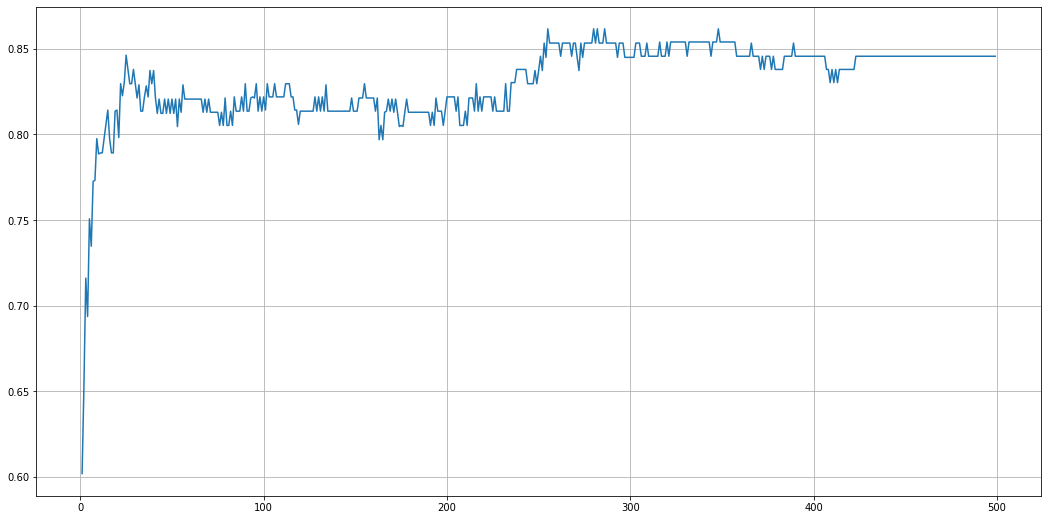

In [170]:
plot_graph(lists[0], lists[1])

>From the plot above I decided to choose n_estimators = 20. After this number the accuracy grows not so fast.

In [171]:
model = RandomForestClassifier(n_estimators=20, criterion='gini', random_state=1)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
print(f"Test accuracy score with gini is: {accuracy_score(y_test, y_pred)}")
print(f"Cross_val_score with gini is: {cross_val_score(model, X_train, y_train, scoring='accuracy', cv=30).mean()}")


model = RandomForestClassifier(n_estimators=20, criterion='entropy', random_state=1)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
print(f"Test accuracy score with entropy is: {accuracy_score(y_test, y_pred)}")
print(f"Cross_val_score with entropy is: {cross_val_score(model, X_train, y_train, scoring='accuracy', cv=30).mean()}")

Test accuracy score with gini is: 0.7619047619047619
Cross_val_score with gini is: 0.815
Test accuracy score with entropy is: 0.7619047619047619
Cross_val_score with entropy is: 0.7816666666666666


> The Gini criterion tended to give higher accuracy. So let's use it further as a split criterion. 

In [177]:
def depth_number(n_depth):
    list_n, list_acc = [], []
    for n in range(1, n_depth, 1):
        model = RandomForestClassifier(n_estimators=20, criterion='gini', max_depth = n, random_state=1)
        accuracy = cross_val_score(model, X_train, y_train, scoring='accuracy', cv=10).mean()
        list_n.append(n)
        list_acc.append(accuracy)
    return list_n, list_acc  

In [178]:
depth_lists = depth_number(300)

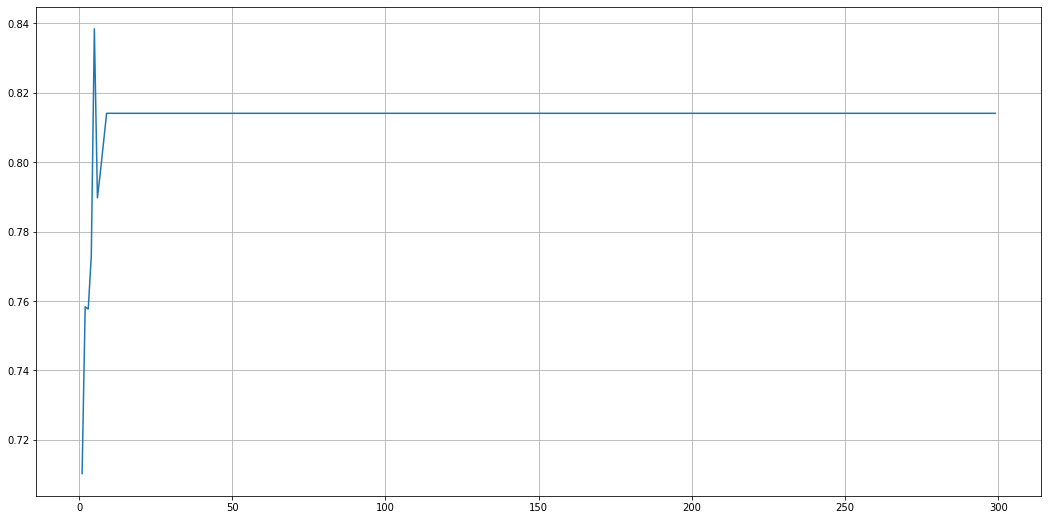

In [179]:
plot_graph(depth_lists[0], depth_lists[1])

>It is clearly can be seen that max accuracy is when max_depth=5. Let's fix this value.

In [182]:
model = RandomForestClassifier(n_estimators=20, criterion='gini', max_depth=5, random_state=1)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
print(f"Test accuracy score is: {accuracy_score(y_test, y_pred)}")
print(f"Cross_val_score is: {cross_val_score(model, X_train, y_train, scoring='accuracy', cv=30).mean()}")

Test accuracy score is: 0.8095238095238095
Cross_val_score is: 0.7883333333333333


In [194]:
def min_samples_number(n_split):
    list_n, list_acc = [], []
    for n in range(2, n_split):
        model = RandomForestClassifier(n_estimators=20, criterion='gini', max_depth =5, min_samples_split = n, random_state=1)
        accuracy = cross_val_score(model, X_train, y_train, scoring='accuracy', cv=10).mean()
        list_n.append(n)
        list_acc.append(accuracy)
    return list_n, list_acc  

In [195]:
split_sample_lists = min_samples_number(50)

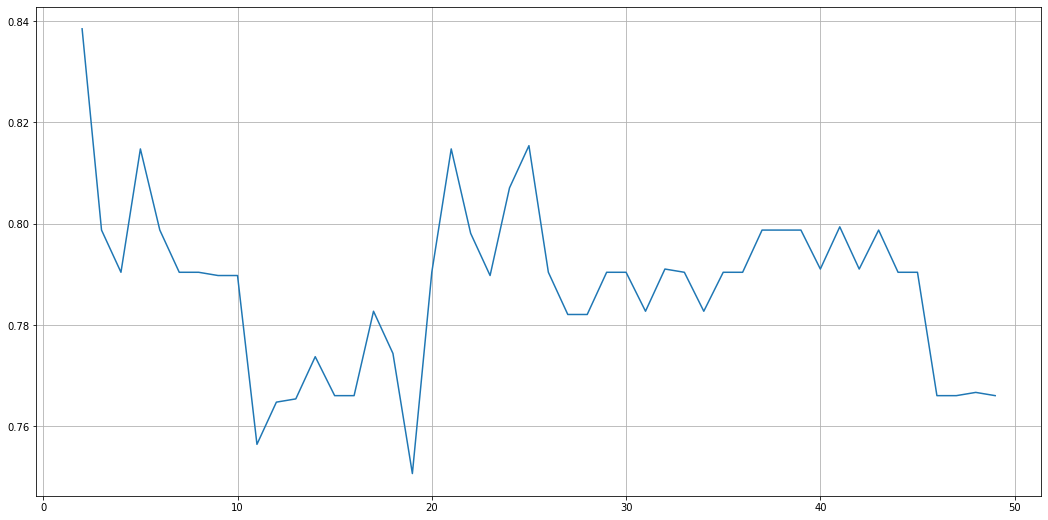

In [196]:
plot_graph(split_sample_lists[0], split_sample_lists[1])

> From the plot above the best min_samples_split is 5. Let's fix it. If we take 2, then our model risks to be overfitted. 

In [198]:
model = RandomForestClassifier(n_estimators=20, criterion='gini', max_depth=5, min_samples_split=5, random_state=1)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
print(f"Test accuracy score is: {accuracy_score(y_test, y_pred)}")
print(f"Cross_val_score is: {cross_val_score(model, X_train, y_train, scoring='accuracy', cv=30).mean()}")

Test accuracy score is: 0.7857142857142857
Cross_val_score is: 0.8133333333333332


In [201]:
def min_leaf_number(n_leaf):
    list_n, list_acc = [], []
    for n in range(1, n_leaf, 1):
        model = RandomForestClassifier(n_estimators=20, criterion='gini', max_depth =5, min_samples_split =5, min_samples_leaf = n, random_state=1)
        accuracy = cross_val_score(model, X_train, y_train, scoring='accuracy', cv=10).mean()
        list_n.append(n)
        list_acc.append(accuracy)
    return list_n, list_acc  

In [202]:
sample_leaf_lists = min_leaf_number(50)

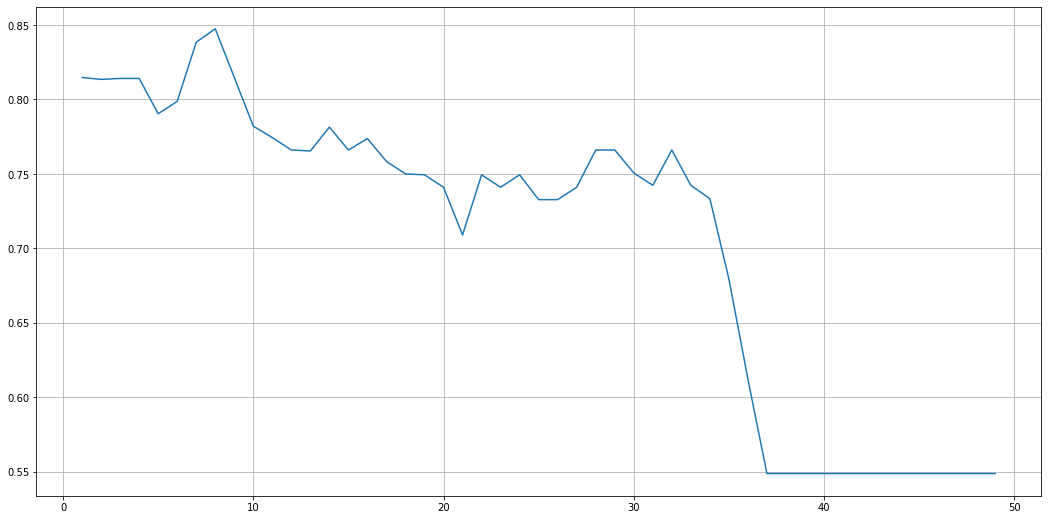

In [203]:
plot_graph(sample_leaf_lists[0], sample_leaf_lists[1])

> From the plot above the best min_samples_leaf is 8. Let's fix it. 

In [208]:
model = RandomForestClassifier(n_estimators=20, criterion='gini', max_depth=5, min_samples_split=5, min_samples_leaf=8, random_state=1)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
print(f"Test accuracy score with gini is: {accuracy_score(y_test, y_pred)}")
print(f"Cross_val_score with gini is: {cross_val_score(model, X_train, y_train, scoring='accuracy', cv=30).mean()}")

Test accuracy score with gini is: 0.7380952380952381
Cross_val_score with gini is: 0.7799999999999999


> We fixed all parameters, let's increase the number of trees and see whether it gives a significant score improvement.

In [209]:
def trees_number_after(n_estim):
    list_n, list_acc = [], []
    for n in range(20, n_estim, 1):
        model = RandomForestClassifier(n_estimators=n, criterion='gini', max_depth=5, min_samples_split=5, min_samples_leaf=8, random_state=1)
        accuracy = cross_val_score(model, X_train, y_train, scoring='accuracy', cv=10).mean()
        list_n.append(n)
        list_acc.append(accuracy)
    return list_n, list_acc 

In [210]:
after_lists = trees_number_after(100)

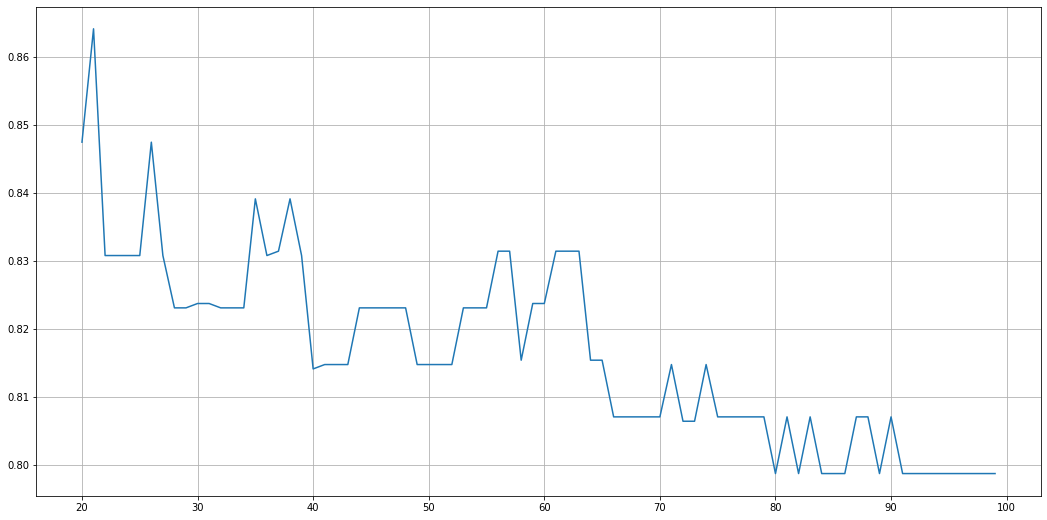

In [211]:
plot_graph(after_lists[0], after_lists[1])

> So it is obvious that there is no need to increase the number of trees. Let's measure accuracy on the validation set.

In [217]:
model = RandomForestClassifier(n_estimators=20, criterion='gini', max_depth=5, min_samples_split=5, min_samples_leaf=8, random_state=1)
model.fit(X_train, y_train)
y_pred = model.predict(X_val)
print(f"Validation accuracy score with best parameters is: {accuracy_score(y_val, y_pred)}")

Validation accuracy score with best parameters is: 0.7142857142857143


### Grid Search and Random Search

If you have enough computational power for model training in a reasonable amount of time more sophisticated approach of hyperparameter tuning would be either Grid Search or Random Search.<br>

In a nutshell Grid Search allows you to pass through all different combinations of given model parameters and their values and choose the best combination. Whereas Random Search would randomly choose values for given model parameters and evaluate them on test data untill it reaches the specified number of iterations.<br>

More information here [Gentle introduction to Grid and Random search](https://medium.com/@senapati.dipak97/grid-search-vs-random-search-d34c92946318) and here [Detailed Explanation with code examples](https://machinelearningmastery.com/hyperparameter-optimization-with-random-search-and-grid-search/).

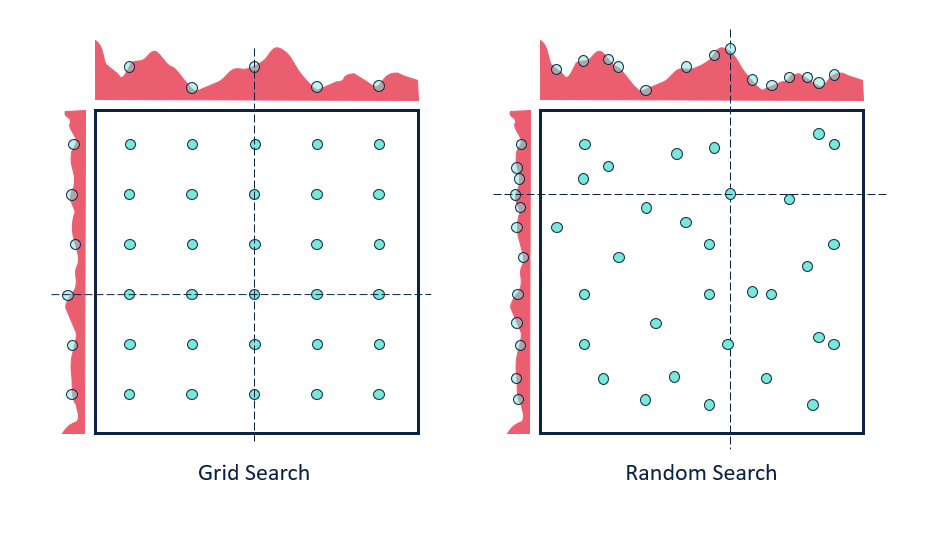

**Task 3 (1 point)**. Compare your previous results with [GridSearch](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.GridSearchCV.html) hyperparameter tuning. You may tune best hyperparameters for forest with several trees and then increase it while measure the quality on validation dataset.

In [218]:
from sklearn.model_selection import GridSearchCV, RepeatedStratifiedKFold

In [219]:
# Your code here
model = RandomForestClassifier()

cv = RepeatedStratifiedKFold(n_splits=10, n_repeats=3, random_state=1)
space = dict()
space['n_estimators'] = range(1, 10)
space['criterion'] = ['gini', 'entropy']
space['max_depth'] = range(1, 10)
space['min_samples_split'] = range(2, 15)
space['min_samples_leaf'] = range(1, 20)

search = GridSearchCV(model, space, scoring='accuracy', cv=cv)
result = search.fit(X_train, y_train)
print('best accuracy is:', result.best_score_)
print('optimal parameters are:', result.best_params_)

best accuracy is: 0.8183760683760682
optimal parameters are: {'criterion': 'entropy', 'max_depth': 7, 'min_samples_leaf': 8, 'min_samples_split': 10, 'n_estimators': 8}


In [220]:
model = RandomForestClassifier(n_estimators=8, criterion='entropy', max_depth=7, min_samples_split=10, min_samples_leaf=8, random_state=1)
model.fit(X_train, y_train)
y_pred = model.predict(X_val)
print(f"Validation accuracy score with best GridSearched parameters is: {accuracy_score(y_val, y_pred)}")

Validation accuracy score with best GridSearched parameters is: 0.7857142857142857


In [222]:
model = RandomForestClassifier(criterion='entropy', max_depth=7, min_samples_split=10, min_samples_leaf=8, random_state=1)

cv = RepeatedStratifiedKFold(n_splits=5, n_repeats=2, random_state=1)
space = dict()
space['n_estimators'] = range(10, 30)

search = GridSearchCV(model, space, scoring='accuracy', cv=cv)
result = search.fit(X_train, y_train)
print('best accuracy is:', result.best_score_)
print('optimal parameters are:', result.best_params_)

best accuracy is: 0.8261666666666667
optimal parameters are: {'n_estimators': 28}


In [223]:
model = RandomForestClassifier(n_estimators=28, criterion='entropy', max_depth=7, min_samples_split=10, min_samples_leaf=8, random_state=1)
model.fit(X_train, y_train)
y_pred = model.predict(X_val)
print(f"Validation accuracy score with best GridSearched parameters is: {accuracy_score(y_val, y_pred)}")

Validation accuracy score with best GridSearched parameters is: 0.7619047619047619


**Task 4 (1 point)**. And finally tune forest hyperparameters with [RandomSearch](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.RandomizedSearchCV.html). Compare results to previous attempts.

In [225]:
from sklearn.model_selection import RandomizedSearchCV

In [226]:
# Your code here
model = RandomForestClassifier()

cv = RepeatedStratifiedKFold(n_splits=5, n_repeats=2, random_state=1)
space = dict()
space['n_estimators'] = range(1, 10)
space['criterion'] = ['gini', 'entropy']
space['max_depth'] = range(1, 10)
space['min_samples_split'] = range(2, 15)
space['min_samples_leaf'] = range(1, 20)

search = RandomizedSearchCV(model, space, n_iter=300, scoring='accuracy', cv=cv)
result = search.fit(X_train, y_train)
print('best accuracy is:', result.best_score_)
print('optimal parameters are:', result.best_params_)

best accuracy is: 0.7983333333333333
optimal parameters are: {'n_estimators': 8, 'min_samples_split': 11, 'min_samples_leaf': 9, 'max_depth': 9, 'criterion': 'gini'}


In [227]:
model = RandomForestClassifier(n_estimators=8, criterion='gini', max_depth=9, min_samples_split=11, min_samples_leaf=9, random_state=1)
model.fit(X_train, y_train)
y_pred = model.predict(X_val)
print(f"Validation accuracy score with best RandomSearched parameters is: {accuracy_score(y_val, y_pred)}")

Validation accuracy score with best RandomSearched parameters is: 0.7857142857142857


In [230]:
model = RandomForestClassifier(criterion='gini', max_depth=9, min_samples_split=11, min_samples_leaf=9, random_state=1)

cv = RepeatedStratifiedKFold(n_splits=5, n_repeats=2, random_state=1)
space = dict()
space['n_estimators'] = range(10, 500)

search = RandomizedSearchCV(model, space, n_iter=300, scoring='accuracy', cv=cv)
result = search.fit(X_train, y_train)
print('best accuracy is:', result.best_score_)
print('optimal parameters are:', result.best_params_)

best accuracy is: 0.8143333333333335
optimal parameters are: {'n_estimators': 14}


In [231]:
model = RandomForestClassifier(n_estimators=14, criterion='gini', max_depth=9, min_samples_split=11, min_samples_leaf=9, random_state=1)
model.fit(X_train, y_train)
y_pred = model.predict(X_val)
print(f"Validation accuracy score with best RandomSearched parameters is: {accuracy_score(y_val, y_pred)}")

Validation accuracy score with best RandomSearched parameters is: 0.7380952380952381


**Task 5 (0.5 points)**. Tell us about your experience in hyperparameter tuning with the approaches above. What do you think would be the best option for this task and why?

>I think that there is no one guaranteed way for hyperparameter tuning. In this particular case the best result (validation score=0.7857) was achieved by both Grid and Random Search. Manually greedy search was not so successful because fixing the best hyperparameter on each step lead to putting some cool combinations out of the scene.  

>Each method has its own pros and cons. 
- You can control manually "greedy" tuninig (but you can miss some wining combinations).
- Grid search is fundamental but requires a lot of time.
- Random search is your lucky ticket and its fast (but here you rely on chance).

>Given the fact that RandomForestClassifier is really random, almost every time you can get a different score result (unless you take a fixed random_state). And even if you choose the highest, there is no confidence that validation score will be great.

>So the final conclusion is to try all approaches (if you have enough time and computational power) or try the most suitable one. 

### Desicion tree explained

Remember the [Titanic](https://www.kaggle.com/c/titanic) competition from last week? Wouldn't be a good idea to visualize one of possible desicion-making processes of _survived_ / _dead_ labeling?

**Task 6 (1 point)**. Load titanic dataset, split it into train/test parts, apply simple hyperparameter tuning of [DesicionTreeClassifier](https://scikit-learn.org/stable/modules/generated/sklearn.tree.DecisionTreeClassifier.html) (use one of the approaches above) in order to have **test accuracy more than 0.65**. <br>

Draw the best tree decision making process. You may use [sklearn.tree.prot_tree](https://scikit-learn.org/stable/modules/generated/sklearn.tree.plot_tree.html).<br>

In [233]:
from sklearn.tree import DecisionTreeClassifier
import os
# your code here

In [234]:
PATH = "./data/"
data = pd.read_csv(os.path.join(PATH, 'titanic', 'train.csv')).set_index('PassengerId')

In [235]:
data['Age'].fillna(data['Age'].median(), inplace=True)
data['Embarked'].fillna(data['Embarked'].mode(), inplace=True)

In [236]:
data['Sex'] = data['Sex'].apply(lambda x: 0 if x == 'female' else 1)
data['Embarked'] = data['Embarked'].apply(lambda x: 0 if x == 'S' else (1 if x == 'C' else 2))

In [237]:
y = data['Survived']
x = data[['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked']]

In [238]:
X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.3, random_state=1)

In [239]:
model = DecisionTreeClassifier()

cv = RepeatedStratifiedKFold(n_splits=5, n_repeats=2, random_state=1)
space = dict()
space['splitter'] = ['best', 'random']
space['criterion'] = ['gini', 'entropy']
space['max_depth'] = range(1, 10)
space['min_samples_split'] = range(2, 15)
space['min_samples_leaf'] = range(1, 20)
space['random_state'] = range(1, 100)

search = RandomizedSearchCV(model, space, n_iter=300, scoring='accuracy', cv=cv)
result = search.fit(X_train, y_train)
print('best accuracy is:', result.best_score_)
print('optimal parameters are:', result.best_params_)

best accuracy is: 0.8491225806451613
optimal parameters are: {'splitter': 'random', 'random_state': 58, 'min_samples_split': 12, 'min_samples_leaf': 7, 'max_depth': 7, 'criterion': 'entropy'}


In [242]:
model = DecisionTreeClassifier(splitter='random', criterion='entropy', max_depth=7, min_samples_split=12, min_samples_leaf=7, random_state=58)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
print(f"Test accuracy score with best RandomSearched parameters is: {accuracy_score(y_test, y_pred)}")

Test accuracy score with best RandomSearched parameters is: 0.7388059701492538


In [241]:
test_data = pd.read_csv(os.path.join(PATH, 'titanic', 'test.csv'))

In [243]:
test_data['Age'].fillna(test_data['Age'].median(), inplace=True)
test_data['Fare'].fillna(test_data['Fare'].median(), inplace=True)

In [244]:
test_data['Sex'] = test_data['Sex'].apply(lambda x: 0 if x == 'female' else 1)
test_data['Embarked'] = test_data['Embarked'].apply(lambda x: 0 if x == 'S' else (1 if x == 'C' else 2))

In [247]:
X_test = test_data[['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked']]

In [248]:
preds = model.predict(X_test)

In [249]:
# Kaggle score 0.76555
output = pd.DataFrame({'PassengerId': test_data.PassengerId, 'Survived': preds})
output.to_csv('my_submission1.csv', index=False)

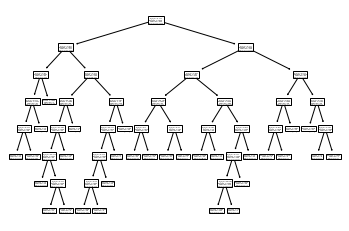

In [251]:
from sklearn import tree
tree.plot_tree(model)
plt.show()

In [252]:
n_nodes = model.tree_.node_count
children_left = model.tree_.children_left
children_right = model.tree_.children_right
feature = model.tree_.feature
threshold = model.tree_.threshold

node_depth = np.zeros(shape=n_nodes, dtype=np.int64)
is_leaves = np.zeros(shape=n_nodes, dtype=bool)
stack = [(0, 0)]  # start with the root node id (0) and its depth (0)
while len(stack) > 0:
    # `pop` ensures each node is only visited once
    node_id, depth = stack.pop()
    node_depth[node_id] = depth

    # If the left and right child of a node is not the same we have a split
    # node
    is_split_node = children_left[node_id] != children_right[node_id]
    # If a split node, append left and right children and depth to `stack`
    # so we can loop through them
    if is_split_node:
        stack.append((children_left[node_id], depth + 1))
        stack.append((children_right[node_id], depth + 1))
    else:
        is_leaves[node_id] = True

print("The binary tree structure has {n} nodes and has "
      "the following tree structure:\n".format(n=n_nodes))
for i in range(n_nodes):
    if is_leaves[i]:
        print("{space}node={node} is a leaf node.".format(
            space=node_depth[i] * "\t", node=i))
    else:
        print("{space}node={node} is a split node: "
              "go to node {left} if X[:, {feature}] <= {threshold} "
              "else to node {right}.".format(
                  space=node_depth[i] * "\t",
                  node=i,
                  left=children_left[i],
                  feature=feature[i],
                  threshold=threshold[i],
                  right=children_right[i]))

The binary tree structure has 59 nodes and has the following tree structure:

node=0 is a split node: go to node 1 if X[:, 1] <= 0.14274651051626844 else to node 28.
	node=1 is a split node: go to node 2 if X[:, 0] <= 1.8652656985750729 else to node 9.
		node=2 is a split node: go to node 3 if X[:, 4] <= 1.980450890949206 else to node 8.
			node=3 is a split node: go to node 4 if X[:, 3] <= 0.605726661908313 else to node 7.
				node=4 is a split node: go to node 5 if X[:, 6] <= 0.42626077887893693 else to node 6.
					node=5 is a leaf node.
					node=6 is a leaf node.
				node=7 is a leaf node.
			node=8 is a leaf node.
		node=9 is a split node: go to node 10 if X[:, 0] <= 2.3180442225737705 else to node 19.
			node=10 is a split node: go to node 11 if X[:, 5] <= 32.185385467338094 else to node 18.
				node=11 is a split node: go to node 12 if X[:, 2] <= 37.93774606936506 else to node 17.
					node=12 is a split node: go to node 13 if X[:, 2] <= 22.07345853376829 else to node 14.
					

Is it easy to interpret its results? Are you able to explain to a random person why would he survive / die on the titanic?

>No, even with such an iterpretation it is not easy to interpret results. Our tree is rather complicated, it has 59 nodes. And it will take a lot of time to go top-down (without any mistake) and to find a final prediction.

# Homework part 2. RandomForestRegressor

**Task 7 (2 points)**. Write your own *DecisionTreeRegressor* class with _MSE_ split criterion and settable parameter *max_depth*. Demonstrate its consistency on the proposed artificial data (or some other) by comparing MSE of train predictions with [sklearn.tree.DecisionTreeRegressor](https://scikit-learn.org/stable/modules/generated/sklearn.tree.DecisionTreeRegressor.html). <br>

Provide examples for different _max_depth_ parameter.

Of course you may re-use code for *DecisionTreeClassifier*. You need to figure out what needs to be changed in it for Classification -> Regression transformation.<br>

**! You are allowed to use only NumPy library** in this assigment.

In [3]:
import numpy as np

def f(X):
    return X[:, 0]**3 + np.log(np.exp(X[:, 1]) + np.exp(X[:, 2])) + np.sqrt(abs(X[:, 3])) * X[:, 4]

n_samples = 100

stdv = 1. / np.sqrt(5)

X = np.random.uniform(-stdv, stdv, size = (n_samples, 5))
y = f(X)

In [4]:
def mse(true_values):
    pred_values = np.mean(true_values)
    mse = np.mean((true_values - pred_values) ** 2)
    return mse

def mse_gain(splits):
    return np.sum([mse(split) for split in splits])

In [37]:
class RegressionTree(object):
    """A regression tree classifier.

    Args:
        criterion : {"mse_gain"}
    """
    def __init__(self, criterion=None, max_depth=None):
        self.impurity = None
        self.threshold = None
        self.column_index = None
        self.outcome_preds = None
        self.criterion = criterion
        self.left_child = None
        self.right_child = None
        self.max_depth = max_depth
        np.random.RandomState(42)

    @property
    def is_terminal(self):
        """ Define is it terminal node
        """          
        return not bool(self.left_child and self.right_child)

    def _find_splits(self, X):
        """Find all possible split values."""
        split_values = set()

        # Get unique values in a sorted order
        x_unique = list(np.unique(X))
        for i in range(1, len(x_unique)):
            # Find a point between two values
            average = (x_unique[i - 1] + x_unique[i]) / 2.0
            split_values.add(average)

        return list(split_values)

    def _find_best_split(self, X, y, n_features):
        """Find best feature and value for a split. Greedy algorithm."""

        # Sample random subset of features
        np.random.RandomState(42)
        subset = random.sample(list(range(0, X.shape[1])), n_features)
        min_gain, min_col, min_val = None, None, None

        for column in subset:
            split_values = self._find_splits(X[:, column])
            for value in split_values:
                splits = split(X[:, column], y, value)
                gain = self.criterion(splits)

                if (min_gain is None) or (gain < min_gain):
                    min_col, min_val, min_gain = column, value, gain
        return min_col, min_val, min_gain

    def fit(self, X, y, n_features=None, ):
        """Fit model.

        Args:
            X (numpy-array): The training input samples. 2-dimensional numpy array.
            y (numpy-array): The target values. 1-dimensional numpy array.
            n_features (int): The number of features when fit is performed (default: all features)
            max_depth (int): The maximum depth of the tree. If None, then nodes are expanded until
                             all leaves are pure.
        """        
        try:
            # Exit from recursion using assert syntax
            if self.max_depth is not None:
                assert self.max_depth > 0
                self.max_depth -= 1

            if n_features is None:
                n_features = X.shape[1]

            column, value, gain = self._find_best_split(X, y, n_features)
            assert gain is not None

            self.column_index = column
            self.threshold = value
            self.impurity = gain

            # Split dataset
            left_X, right_X, left_target, right_target = split_dataset(X, y, column, value)

            # Grow left and right child
            self.left_child = RegressionTree(self.criterion, self.max_depth)
            self.left_child.fit(
                left_X, left_target, n_features
            )

            self.right_child = RegressionTree(self.criterion, self.max_depth)
            self.right_child.fit(
                right_X, right_target, n_features
            )
        except AssertionError:
            self.outcome_preds = np.mean(y)


    def predict_row(self, row):
        """Predict single row."""
        if not self.is_terminal:
            if row[self.column_index] < self.threshold:
                return self.left_child.predict_row(row)
            else:
                return self.right_child.predict_row(row)
        return self.outcome_preds

    def predict(self, X):
        """Make predictions.

        Args:
            X (numpy-array): The test input samples. 2-dimensional numpy array.
        """  
        result = np.zeros(X.shape[0])
        for i in range(X.shape[0]):
            result[i] = self.predict_row(X[i, :])
        return result

In [38]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=1)

In [39]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error
from sklearn.tree import DecisionTreeRegressor

In [49]:
model = RegressionTree(criterion=mse_gain)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
print('Custom model MSE, max_depth=None:', mean_squared_error(y_test, y_pred))

Custom model MSE, max_depth=None: 0.030570299393088033


In [50]:
model = DecisionTreeRegressor(criterion='mse', random_state=42)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
print('Sklearn model MSE, max_depth=None:', mean_squared_error(y_test, y_pred))

Sklearn model MSE, max_depth=None: 0.012235913733661362


In [51]:
model = RegressionTree(criterion=mse_gain, max_depth=2)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
print('Custom model MSE, max_depth=2:', mean_squared_error(y_test, y_pred))

Custom model MSE, max_depth=2: 0.052101236261515436


In [52]:
model = DecisionTreeRegressor(criterion='mse', random_state=42, max_depth=2)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
print('Sklearn model MSE, max_depth=2:', mean_squared_error(y_test, y_pred))

Sklearn model MSE, max_depth=2: 0.028670841970803218


In [53]:
model = RegressionTree(criterion=mse_gain, max_depth=5)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
print('Custom model MSE, max_depth=5:', mean_squared_error(y_test, y_pred))

Custom model MSE, max_depth=5: 0.05602615894456504


In [54]:
model = DecisionTreeRegressor(criterion='mse', random_state=42, max_depth=5)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
print('Sklearn model MSE, max_depth=5:', mean_squared_error(y_test, y_pred))

Sklearn model MSE, max_depth=5: 0.01586999755424714


>As we can see, the custom and sklearn tree regressors have some difference in MSE, but it's not very big. 
It can be explained by the fact that sklearn model is more complicated, and there are more hyperparameters that can be tuned.

**Task 8 (2 points)**. Write your own _RandomForestRegressor_ class with MSE split criterion and settable parameter _max_depth_.  Demonstrate its consistency on the proposed artificial data (or some other) by comparing MSE of train predictions with [sklearn.ensemble.RandomForestRegressor](https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.RandomForestRegressor.html).<br>

Provide examples for different max_depth parameter.<br>

**! You are allowed to use only NumPy library** in this assigment.

In [64]:
# Your code here
class RandomForestRegressor_1(object):
    """
    A random forest regressor.
    A random forest is a meta estimator that fits a number of regression tree
    classifiers on various sub-samples of the dataset and uses averaging to
    improve the predictive accuracy and control overfitting.
    
    Args:
        n_estimators : int, default=10
            The number of trees in the forest.

        max_depth : int, default=None
            The maximum depth of the tree. If None, then nodes are expanded until
            all leaves are pure.        

        n_features : int, default=None
            The number of features to consider when looking for the best split.
            If None, then `n_features=sqrt(n_features)`.

        criterion : {"mse_gain"}, default="mse_gain"
            The function to measure the quality of a split. 
    """

    def __init__(self, n_estimators=10, max_depth=None, n_features=None, criterion="mse", bootstrap=True):
        self.n_estimators = n_estimators
        self.max_depth = max_depth
        self.n_features = n_features
        self.bootstrap = bootstrap
        
        if criterion == "mse":
            self.criterion = mse_gain
        else:
            raise ValueError(f"Unknown criterion '{criterion}'")
            
        self.trees = [RegressionTree(criterion=self.criterion, max_depth=self.max_depth) for _ in range(n_estimators)]
        
    def _init_data(self, X, y):
        """Ensure data are in the expected format.
        Ensures X and y are stored as numpy ndarrays by converting from an
        array-like object if necessary. 
        Parameters
        Args:
            X : array-like
                Feature dataset.
            y : array-like, default=None
                Target values. By default is required, but if y_required = false
                then may be omitted.
        """
        self.size = len(X)
        
        if not isinstance(X, np.ndarray):
            self.X = np.array(X)
        else:
            self.X = X

        if not isinstance(y, np.ndarray):
            self.y = np.array(y)
        else:
            self.y = y
            
    def bootstrap_data(self, size):
        return np.random.randint(size, size=size)
    
    def fit(self, X, y):
        """Fit model.

        Args:
            X (numpy-array): The training input samples. 2-dimensional numpy array.
            y (numpy-array): The target values. 1-dimensional numpy array.
        """         
        if self.n_features is None:
            self.n_features = int(np.sqrt(X.shape[1]))
        elif X.shape[1] < self.n_features:
            raise ValueError(f"'n_features should be <= n_features'")
            
        self._init_data(X, y)
        
        for tree in self.trees:
            if self.bootstrap:
                idxs = self.bootstrap_data(self.size)
                X = self.X[idxs]
                y = self.y[idxs]
            else:
                X = self.X
                y = self.y
                
            tree.fit(
                X,
                y,
                n_features=self.n_features
            )
            
    def predict(self, X):
        """Make predictions.

        Args:
            X (numpy-array): The test data input samples. 2-dimensional numpy array.
        """            
        if not isinstance(X, np.ndarray):
            X = np.array(X)

        if self.X is not None:
            predictions = np.zeros(len(X))
            for i in range(len(X)):
                row_pred = 0.
                for tree in self.trees:
                    row_pred += tree.predict_row(X[i, :])

                row_pred /= self.n_estimators
                predictions[i] = row_pred
            return predictions  
        else:
            raise ValueError("You should fit a model before `predict`")

In [65]:
from sklearn.ensemble import RandomForestRegressor

In [68]:
# Your code here
model = RandomForestRegressor_1(n_estimators=10, criterion='mse')
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
print('Custom model MSE, max_depth=None:', mean_squared_error(y_test, y_pred))

Custom model MSE, max_depth=None: 0.016607069402763523


In [70]:
model = RandomForestRegressor(n_estimators=10, criterion='mse')
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
print('Sklearn model MSE, max_depth=None:', mean_squared_error(y_test, y_pred))

Sklearn model MSE, max_depth=None: 0.012543520223865153


In [73]:
model = RandomForestRegressor_1(n_estimators=10, criterion='mse', max_depth=2)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
print('Custom model MSE, max_depth=2:', mean_squared_error(y_test, y_pred))

Custom model MSE, max_depth=2: 0.03326620169677865


In [74]:
model = RandomForestRegressor(n_estimators=10, criterion='mse', max_depth=2)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
print('Sklearn model MSE, max_depth=2:', mean_squared_error(y_test, y_pred))

Sklearn model MSE, max_depth=2: 0.012391334554539887


In [81]:
model = RandomForestRegressor_1(n_estimators=10, criterion='mse', max_depth=5, bootstrap=False)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
print('Custom model MSE, max_depth=5:', mean_squared_error(y_test, y_pred))

Custom model MSE, max_depth=5: 0.04013756077971607


In [82]:
model = RandomForestRegressor(n_estimators=10, criterion='mse', max_depth=5, bootstrap=False)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
print('Sklearn model MSE, max_depth=5:', mean_squared_error(y_test, y_pred))

Sklearn model MSE, max_depth=5: 0.012960175035826941


>So we got a RandomForestRegressor_1 class which works pretty similar to RandomForestRegressor from sklearn. Again, we can observe the MSE difference which caused by the general random character of forest and other sklearn hyperparameters default setting which were not fixed in our custom class.

# Homework part 3 (bonus). Speeding up forest training process

**Task 9 (3 points)** Devise a way to speed up training against the default version of our custom _RandomForestClassifier_ or your own _RandomForestRegressor_. You may want use [`joblib`](https://joblib.readthedocs.io/en/latest/) for parallelizing trees training. Provide graphs of time dependences on the number of trees in your _fast_ version with different number of cores / threads used against default one.

In [58]:
# Your code here
from joblib import Parallel, delayed
from math import sqrt
Parallel(n_jobs=1)(delayed(sqrt)(i**2) for i in range(10))

[0.0, 1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0, 8.0, 9.0]

In [16]:
class RandomForestClassifier(object):
    """
    A random forest classifier.
    A random forest is a meta estimator that fits a number of decision tree
    classifiers on various sub-samples of the dataset and uses averaging to
    improve the predictive accuracy and control overfitting.
    
    Args:
        n_estimators : int, default=10
            The number of trees in the forest.

        max_depth : int, default=None
            The maximum depth of the tree. If None, then nodes are expanded until
            all leaves are pure.        

        n_features : int, default=None
            The number of features to consider when looking for the best split.
            If None, then `n_features=sqrt(n_features)`.

        criterion : {"gini", "entropy"}, default="gini"
            The function to measure the quality of a split. Supported criteria are
            "gini" for the Gini impurity and "entropy" for the information gain.
    """

    def __init__(self, n_estimators=10, max_depth=None, n_features=None, criterion="entropy", bootstrap=True):
        self.n_estimators = n_estimators
        self.max_depth = max_depth
        self.n_features = n_features
        self.bootstrap = bootstrap
        
        if criterion == "entropy":
            self.criterion = information_gain
        elif criterion == "gini":
            self.criterion = gini_gain
        else:
            raise ValueError(f"Unknown criterion '{criterion}'")
            
        self.trees = [Tree(criterion=self.criterion) for _ in range(n_estimators)]
        
    def _init_data(self, X, y):
        """Ensure data are in the expected format.
        Ensures X and y are stored as numpy ndarrays by converting from an
        array-like object if necessary. 
        Parameters
        Args:
            X : array-like
                Feature dataset.
            y : array-like, default=None
                Target values. By default is required, but if y_required = false
                then may be omitted.
        """
        self.size = len(X)
        
        if not isinstance(X, np.ndarray):
            self.X = np.array(X)
        else:
            self.X = X

        if not isinstance(y, np.ndarray):
            self.y = np.array(y)
        else:
            self.y = y
            
    def bootstrap_data(self, size):
        return np.random.randint(size, size=size)
    
    def fit(self, X, y):
        """Fit model.

        Args:
            X (numpy-array): The training input samples. 2-dimensional numpy array.
            y (numpy-array): The target values. 1-dimensional numpy array.
        """         
        if self.n_features is None:
            self.n_features = int(np.sqrt(X.shape[1]))
        elif X.shape[1] < self.n_features:
            raise ValueError(f"'n_features should be <= n_features'")
            
        self._init_data(X, y)
        
        for tree in self.trees:
            if self.bootstrap:
                idxs = self.bootstrap_data(self.size)
                X = self.X[idxs]
                y = self.y[idxs]
            else:
                X = self.X
                y = self.y
                
            tree.fit(
                X,
                y,
                n_features=self.n_features,
                max_depth=self.max_depth,
            )
            
    def predict(self, X):
        """Make predictions.

        Args:
            X (numpy-array): The test data input samples. 2-dimensional numpy array.
        """            
        if not isinstance(X, np.ndarray):
            X = np.array(X)

        if self.X is not None:
            predictions = np.zeros(len(X))
            for i in range(len(X)):
                row_pred = 0.
                for tree in self.trees:
                    row_pred += tree.predict_row(X[i, :])

                row_pred /= self.n_estimators
                predictions[i] = round(row_pred)
            return predictions  
        else:
            raise ValueError("You should fit a model before `predict`")